# Exploratory Data Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('Walmart-Sales-Dataset/Data/processed/cleaned_data.csv')
df.head()

,Unnamed: 0,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Year,Month,Week
0,0,1,1,2010-02-05,10.123647,False,A,151315,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,2010,2,5
1,1,1,1,2010-02-12,10.737277,True,A,151315,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,2010,2,6
2,2,1,1,2010-02-19,10.635773,False,A,151315,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,2010,2,7
3,3,1,1,2010-02-26,9.873262,False,A,151315,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,2010,2,8
4,4,1,1,2010-03-05,9.990990,False,A,151315,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,2010,3,9


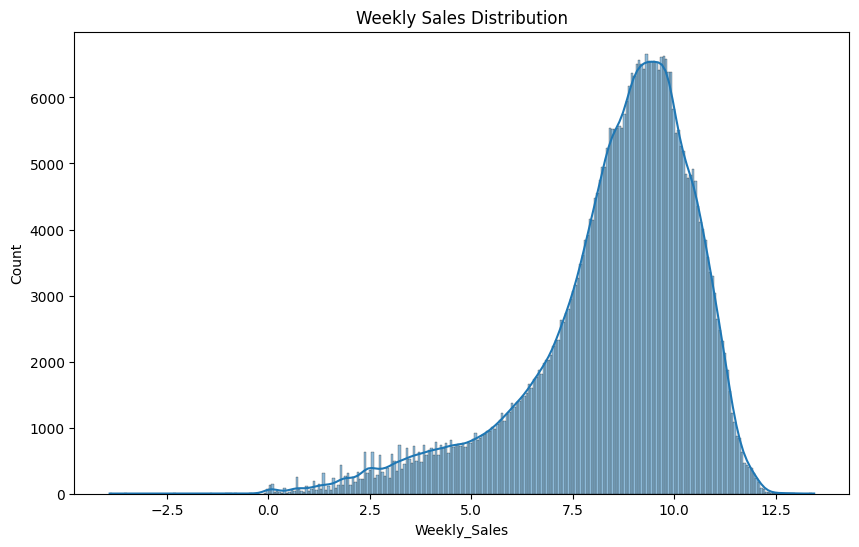

In [3]:
plt.figure(figsize=(10,6))
sns.histplot(df['Weekly_Sales'],kde=True)
plt.title('Weekly Sales Distribution')
plt.show()

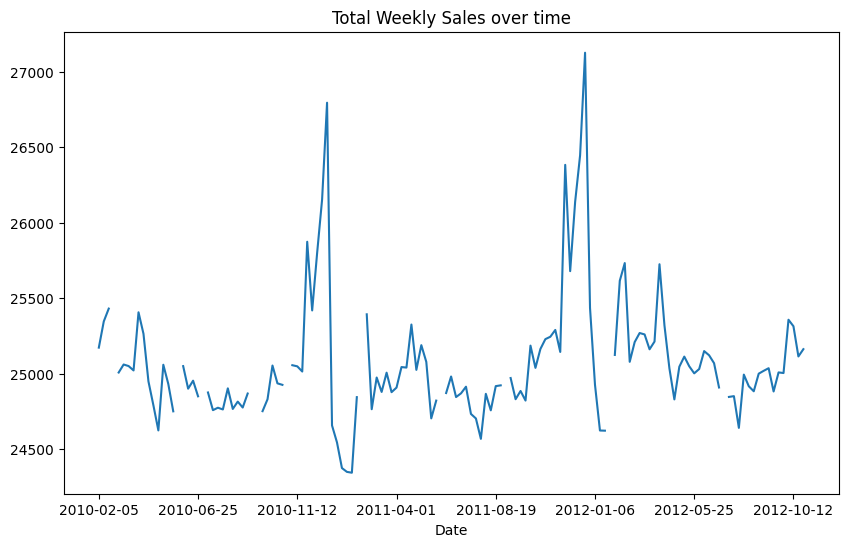

In [4]:
plt.figure(figsize=(10,6))
sales_trends=df.groupby('Date')['Weekly_Sales'].sum()
sales_trends.plot()
plt.title('Total Weekly Sales over time')
plt.show()

Weekly sales exhibit periodic spikes, suggesting strong seasonal effects likely driven by holiday demand. The baseline sales remain relatively stable over time, indicating consistent business performance outside peak periods.

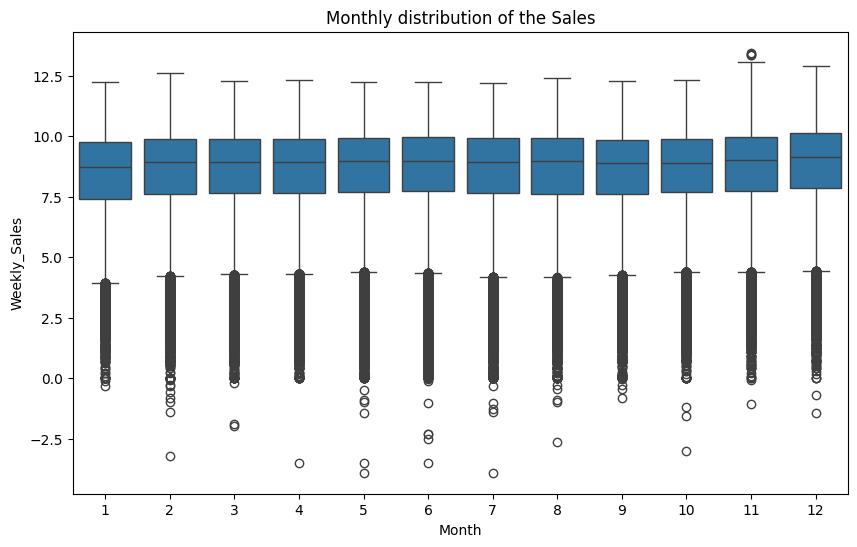

In [5]:
plt.figure(figsize=(10,6))
sns.boxplot(x='Month',y='Weekly_Sales',data=df)
plt.title('Monthly distribution of the Sales')
plt.show()

Sales exhibit strong seasonal behavior, with peak performance in November and December, likely driven by holiday demand. Early months such as January and February show relatively lower sales. Additionally, certain months display higher variability, indicating the influence of promotions and external economic factors.

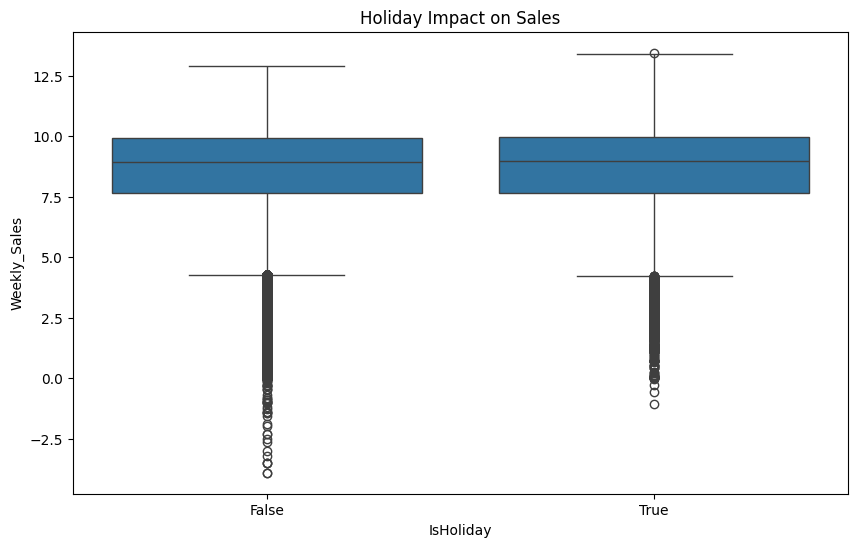

In [6]:
plt.figure(figsize=(10,6))
sns.boxplot(x='IsHoliday',y='Weekly_Sales',data=df)
plt.title('Holiday Impact on Sales')
plt.show()

Weekly sales tend to increase during holiday periods, with slightly higher median values compared to non-holiday weeks. Additionally, the presence of higher extreme values during holidays indicates occasional sales spikes, likely driven by promotional events and increased consumer demand.

In [7]:
store_sales=df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)
store_sales.head()

Store
20    9.417934
4     9.397574
14    9.343490
2     9.340799
13    9.337505
Name: Weekly_Sales, dtype: float64

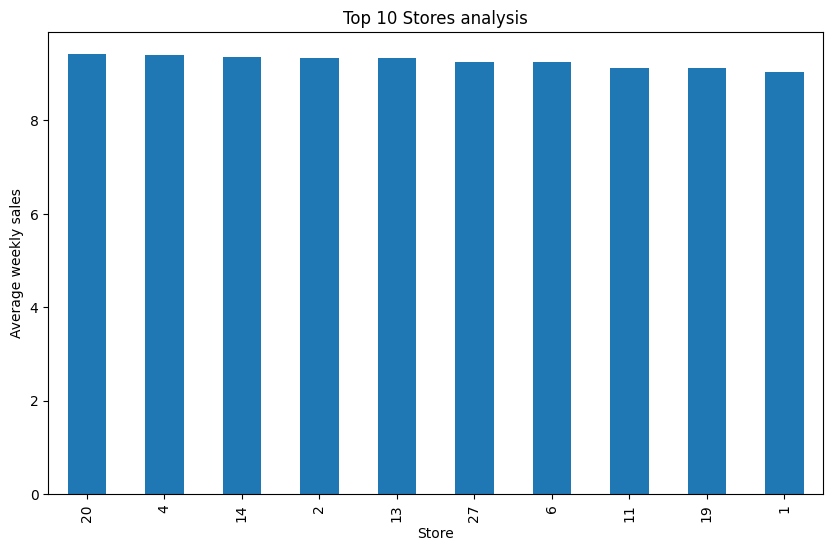

In [9]:
store_sales.head(10).plot(kind='bar',figsize=(10,6))
plt.title('Top 10 Stores analysis')
plt.ylabel('Average weekly sales')
plt.show()

Significant variation exists in average weekly sales across stores, with top-performing stores generating substantially higher revenue than others. This disparity suggests that factors such as store size, type, and regional demand play a crucial role in influencing sales performance.

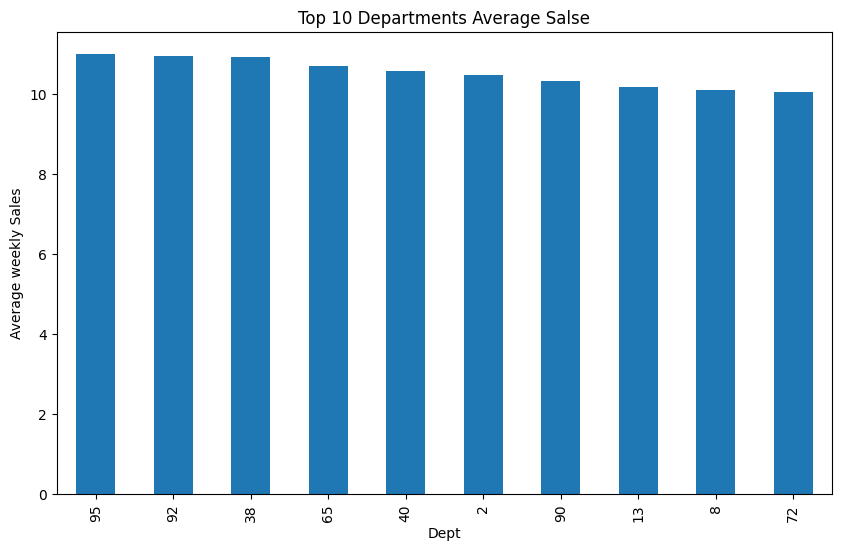

In [12]:
plt.figure(figsize=(10,6))
dept_sales=df.groupby('Dept')['Weekly_Sales'].mean().sort_values(ascending=False)
dept_sales.head(10).plot(kind='bar')
plt.title('Top 10 Departments Average Salse')
plt.ylabel('Average weekly Sales')
plt.show()

Sales are heavily concentrated in a few departments, indicating that certain product categories contribute disproportionately to overall revenue. This highlights the importance of optimizing inventory and marketing strategies around high-performing departments.

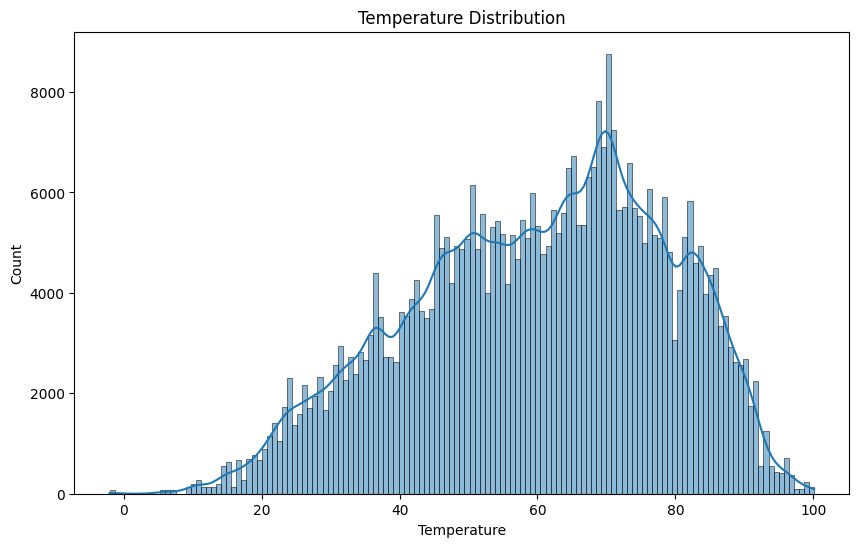

In [13]:
plt.figure(figsize=(10,6))
sns.histplot(df['Temperature'],kde=True)
plt.title('Temperature Distribution')
plt.show()

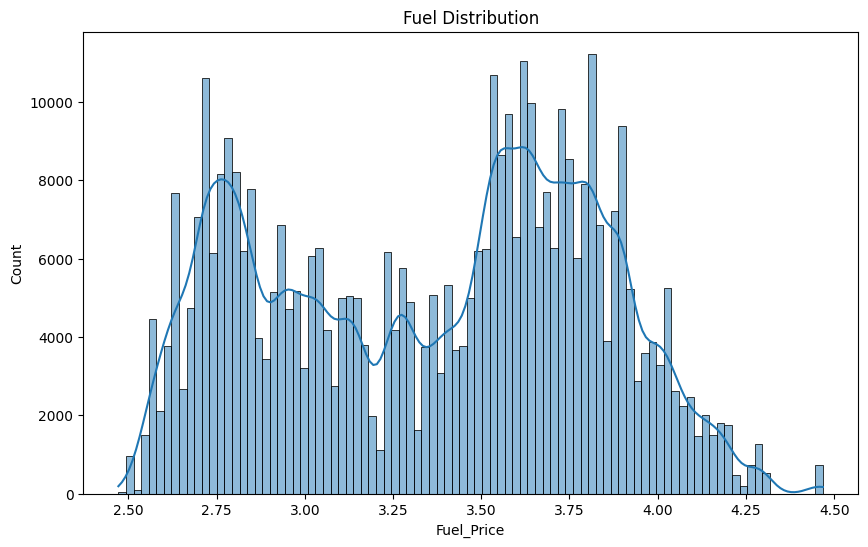

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(df['Fuel_Price'],kde=True)
plt.title('Fuel Distribution')
plt.show()

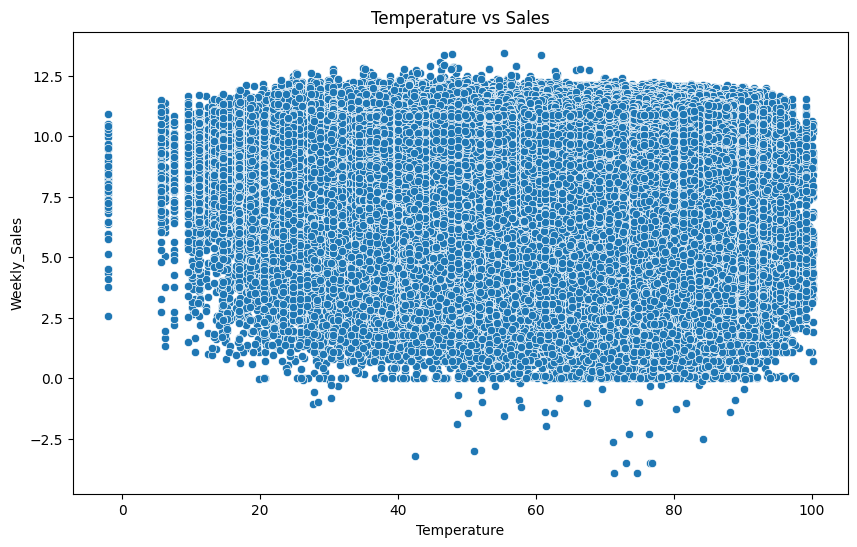

In [16]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Temperature',y='Weekly_Sales',data=df)
plt.title('Temperature vs Sales')
plt.show()

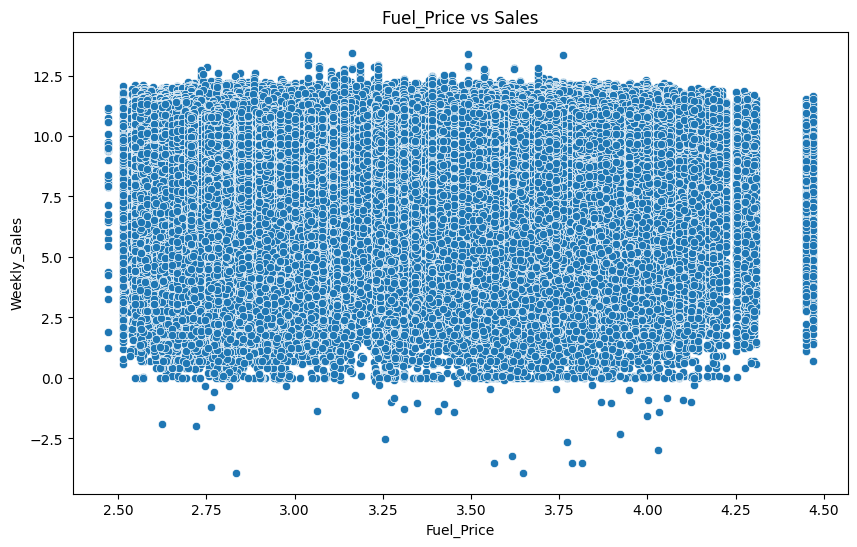

In [17]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Fuel_Price',y='Weekly_Sales',data=df)
plt.title('Fuel_Price vs Sales')
plt.show()

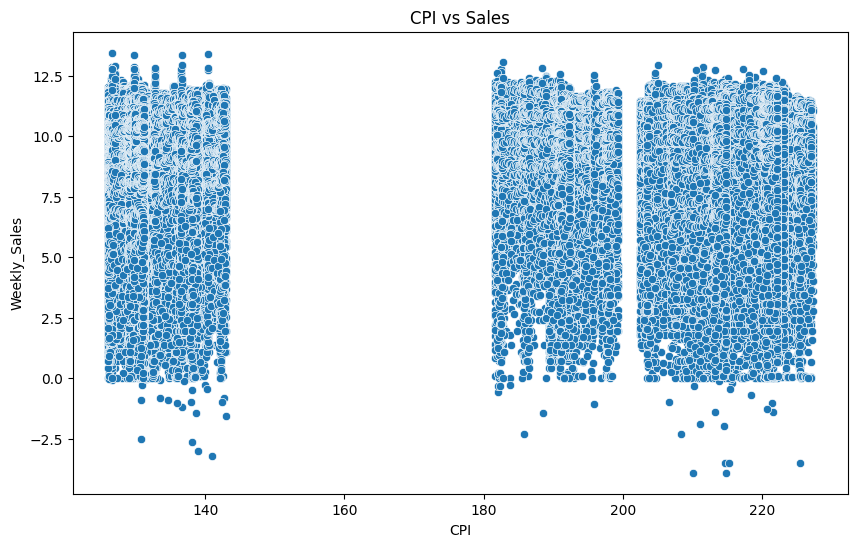

In [18]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='CPI',y='Weekly_Sales',data=df)
plt.title('CPI vs Sales')
plt.show()

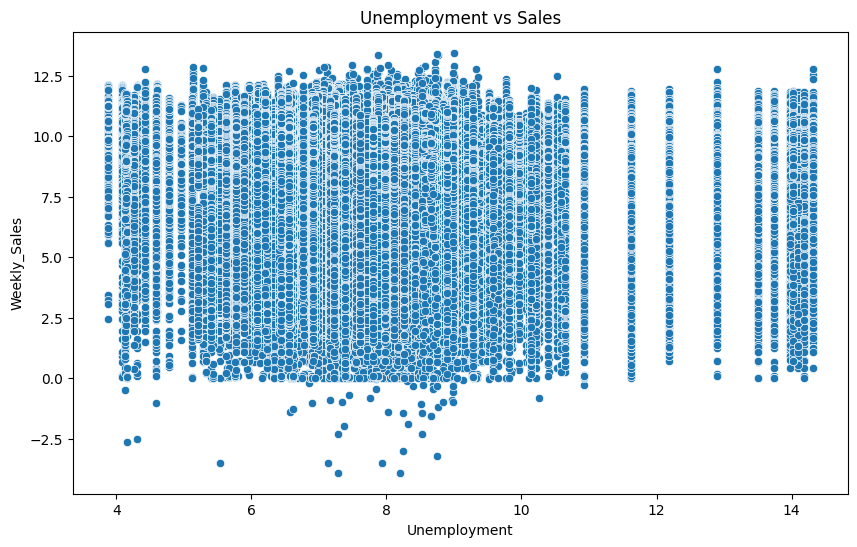

In [20]:
plt.figure(figsize=(10,6))
sns.scatterplot(x='Unemployment',y='Weekly_Sales',data=df)
plt.title('Unemployment vs Sales')
plt.show()

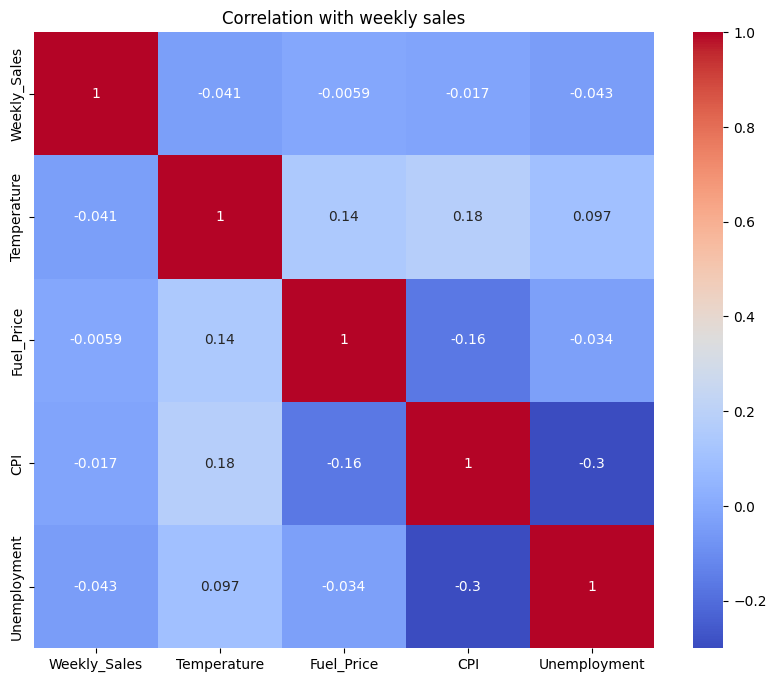

In [22]:
corr = df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap='coolwarm')
plt.title('Correlation with weekly sales')
plt.show()

External factors such as temperature, fuel price, CPI, and unemployment show weak correlation with weekly sales, indicating that internal factors like store characteristics and seasonal demand have a stronger influence on sales performance.

---

## Key Insights

- Weekly sales exhibit strong seasonal patterns, with significant spikes during holiday periods.
- Sales during holidays are consistently higher, with occasional extreme peaks driven by increased demand and promotions.
- There is substantial variation in performance across stores, indicating that store-specific factors such as size, type, and location influence revenue.
- A small number of departments contribute disproportionately to total sales, highlighting category concentration.
- External economic factors such as CPI, fuel price, and unemployment show weak correlation with sales, suggesting limited short-term impact.
- Sales trends remain relatively stable over time outside peak seasonal periods.